In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vaanyakapur/bank-of-thailand-crop-prices-22-25/bot_crop_prices_full_2022_2025.csv
/kaggle/input/datasets/vaanyakapur/thailand-weather-nasa-2022-2025-csv/Thailand_Weather_NASA_2022_2025.csv


# Predictive Rice & Cassava Crop Pricing via Climate Shock Simulation
### Through an Economic Vulnerability & Machine Learning Approach

**Author:** Vaanya Kapur
**Context:** Agriculture employs >30% of the Thai workforce. This project models the economic impact of climate shocks on small-scale farmers using an interpretable Scikit-Learn pipeline.

## Research Question

To what extent can rainfall and temperature anomalies assist in predicting monthly rice and cassava farm-price changes in Thailand?

## Project Output

The final output is a climate shock simulator that estimates the predicted percentage change in crop prices under user-defined rainfall and temperature shock scenarios.

In [2]:
import os
import glob
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## Project Highlights

- Uses official farm-price data for rice and cassava as taken from the Bank of Thailand
- Converts daily NASA weather data into monthly rainfall and temperature anomalies
- Predicts monthly crop price percentage changes
- Includes a climate shock simulator for rainfall and temperature scenarios
- Frames the results through agricultural economics and vulnerability for farmers

In [3]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vaanyakapur/bank-of-thailand-crop-prices-22-25/bot_crop_prices_full_2022_2025.csv
/kaggle/input/datasets/vaanyakapur/thailand-weather-nasa-2022-2025-csv/Thailand_Weather_NASA_2022_2025.csv


In [4]:
all_files = glob.glob("/kaggle/input/**/*", recursive=True)

usable_files = [
    f for f in all_files
    if f.lower().endswith((".csv", ".xlsx", ".txt"))
]

print("Usable data files found:")
for f in usable_files:
    print(f)

weather_path = [
    f for f in usable_files
    if "thailand_weather_nasa" in os.path.basename(f).lower()
][0]

price_path = [
    f for f in usable_files
    if f != weather_path
    and (
        "crop" in f.lower()
        or "bot" in f.lower()
        or "bank" in f.lower()
        or "thailand" in f.lower()
    )
][0]

print("\nSelected weather file:")
print(weather_path)

print("\nSelected price file:")
print(price_path)

Usable data files found:
/kaggle/input/datasets/vaanyakapur/bank-of-thailand-crop-prices-22-25/bot_crop_prices_full_2022_2025.csv
/kaggle/input/datasets/vaanyakapur/thailand-weather-nasa-2022-2025-csv/Thailand_Weather_NASA_2022_2025.csv

Selected weather file:
/kaggle/input/datasets/vaanyakapur/thailand-weather-nasa-2022-2025-csv/Thailand_Weather_NASA_2022_2025.csv

Selected price file:
/kaggle/input/datasets/vaanyakapur/bank-of-thailand-crop-prices-22-25/bot_crop_prices_full_2022_2025.csv


In [5]:
weather_raw = pd.read_csv(weather_path)

print("Weather data shape:", weather_raw.shape)
weather_raw.head()

Weather data shape: (1461, 5)


,Date,Max_Temp,Min_Temp,Mean_Temp,Rainfall
0,2022-01-01,30.86,19.07,24.37,0.0
1,2022-01-02,30.90,18.69,24.42,0.0
2,2022-01-03,31.81,19.10,25.10,0.0
3,2022-01-04,32.67,20.67,26.02,0.0
4,2022-01-05,32.37,20.82,25.99,0.0


In [6]:
weather = weather_raw.copy()

weather.columns = [
    str(c).strip().lower().replace(" ", "_")
    for c in weather.columns
]

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

weather["max_temp"] = pd.to_numeric(weather["max_temp"], errors="coerce")
weather["min_temp"] = pd.to_numeric(weather["min_temp"], errors="coerce")
weather["mean_temp"] = pd.to_numeric(weather["mean_temp"], errors="coerce")
weather["rainfall"] = pd.to_numeric(weather["rainfall"], errors="coerce")

weather = weather.dropna(subset=["date"])

print(weather.shape)
weather.head()

(1461, 5)


,date,max_temp,min_temp,mean_temp,rainfall
0,2022-01-01,30.86,19.07,24.37,0.0
1,2022-01-02,30.90,18.69,24.42,0.0
2,2022-01-03,31.81,19.10,25.10,0.0
3,2022-01-04,32.67,20.67,26.02,0.0
4,2022-01-05,32.37,20.82,25.99,0.0


In [7]:
weather["month"] = weather["date"].dt.to_period("M").dt.to_timestamp()

weather_monthly = (
    weather
    .groupby("month")
    .agg(
        rainfall_mm=("rainfall", "sum"),
        avg_temp_c=("mean_temp", "mean"),
        max_temp_c=("max_temp", "mean"),
        min_temp_c=("min_temp", "mean")
    )
    .reset_index()
)

print(weather_monthly.shape)
weather_monthly.head()

(48, 5)


,month,rainfall_mm,avg_temp_c,max_temp_c,min_temp_c
0,2022-01-01,15.63,26.939355,33.736129,21.249677
1,2022-02-01,79.88,27.325357,33.331071,22.442857
2,2022-03-01,72.52,29.490323,34.867097,25.280968
3,2022-04-01,88.21,29.783000,35.918667,24.833667
4,2022-05-01,237.90,27.936774,31.677742,24.848710


In [8]:
weather_monthly["calendar_month"] = weather_monthly["month"].dt.month

weather_monthly["rainfall_normal"] = (
    weather_monthly
    .groupby("calendar_month")["rainfall_mm"]
    .transform("mean")
)

weather_monthly["temp_normal"] = (
    weather_monthly
    .groupby("calendar_month")["avg_temp_c"]
    .transform("mean")
)

weather_monthly["rainfall_anomaly_pct"] = (
    (weather_monthly["rainfall_mm"] - weather_monthly["rainfall_normal"])
    / weather_monthly["rainfall_normal"]
) * 100

weather_monthly["temp_anomaly_c"] = (
    weather_monthly["avg_temp_c"] - weather_monthly["temp_normal"]
)

weather_monthly = weather_monthly.replace([np.inf, -np.inf], np.nan)

weather_monthly.head(12)

,month,rainfall_mm,avg_temp_c,max_temp_c,min_temp_c,calendar_month,rainfall_normal,temp_normal,rainfall_anomaly_pct,temp_anomaly_c
0,2022-01-01,15.63,26.939355,33.736129,21.249677,1,5.4800,26.071774,185.218978,0.867581
1,2022-02-01,79.88,27.325357,33.331071,22.442857,2,28.9325,28.911875,176.090901,-1.586518
2,2022-03-01,72.52,29.490323,34.867097,25.280968,3,38.5850,30.569677,87.948685,-1.079355
3,2022-04-01,88.21,29.783000,35.918667,24.833667,4,54.1175,31.737750,62.997182,-1.954750
4,2022-05-01,237.90,27.936774,31.677742,24.848710,5,223.6400,30.046048,6.376319,-2.109274
5,2022-06-01,138.22,28.014667,31.539667,25.025000,6,132.2825,28.864250,4.488500,-0.849583
6,2022-07-01,244.42,27.723871,31.094839,24.805484,7,214.8050,28.176048,13.786923,-0.452177
7,2022-08-01,314.94,27.245806,30.533548,24.505806,8,219.7525,28.187500,43.315776,-0.941694
8,2022-09-01,430.84,26.729667,29.520000,24.344000,9,349.4225,27.552083,23.300589,-0.822417
9,2022-10-01,209.67,25.966774,29.734839,22.963548,10,196.8425,27.259758,6.516631,-1.292984


## Weather Feature Engineering

The NASA weather dataset is recorded daily, so it is converted into monthly observations to match the frequency of crop price data.

Two climate stress variables are created:
- Rainfall anomaly (%): how much monthly rainfall differs from the expected rainfall for that calendar month.
- Temperature anomaly (°C): how much the average monthly temperature differs from the expected temperature for that calendar month.

These anomaly variables are more useful than raw weather values because crop markets respond more strongly to unusual weather conditions than to normal seasonal patterns.

In [9]:
price_raw = pd.read_csv(
    price_path,
    header=None,
    skiprows=5,
    encoding="utf-8-sig",
    dtype=str,
    keep_default_na=False,
    engine="python"
)

print("Raw price file shape:", price_raw.shape)
price_raw.head(10)

Raw price file shape: (24, 50)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0,,,DEC 2025,NOV 2025,OCT 2025,SEP 2025,AUG 2025,JUL 2025,JUN 2025,MAY 2025,APR 2025,MAR 2025,FEB 2025,JAN 2025,DEC 2024,NOV 2024,OCT 2024,SEP 2024,AUG 2024,JUL 2024,JUN 2024,MAY 2024,APR 2024,MAR 2024,FEB 2024,JAN 2024,DEC 2023,NOV 2023,OCT 2023,SEP 2023,AUG 2023,JUL 2023,JUN 2023,MAY 2023,APR 2023,MAR 2023,FEB 2023,JAN 2023,DEC 2022,NOV 2022,OCT 2022,SEP 2022,AUG 2022,JUL 2022,JUN 2022,MAY 2022,APR 2022,MAR 2022,FEB 2022,JAN 2022
1,1,Major Rice 5% (Baht/Mt.),6873.6,6621.3,6733.2,6752.4,6756.1,-,-,-,-,-,-,9914.9,10075.6,10089.9,10068.6,10975.7,10979.8,-,-,-,-,-,-,11152.9,11018.9,11144.4,11722.8,11653.6,10988.4,-,-,-,-,-,-,9537.3,9317.4,9294.3,9114.4,9312.8,9021.0,-,-,-,-,-,-,7507.9
2,2,Glutinous (Baht/Mt.),10879.5,10793.5,11465.2,12359.7,12513.4,12469.5,12426.9,12423.0,12345.4,12198.8,12274.9,12272.0,12190.4,12519.7,12397.9,12311.3,12283.9,12143.5,12098.3,12049.1,11648.4,11255.6,11467.2,11508.3,11785.1,11885.4,12469.7,11937.1,11645.1,10961.4,10889.3,10759.9,10672.0,10341.0,10270.2,10418.9,9965.3,9459.2,9028.2,8831.6,8422.6,8377.0,8139.0,7825.4,8049.3,8230.2,8618.9,7997.9
3,3,Second Rice 14-15% (Baht/Mt.),-,-,-,-,-,7079.4,7285.9,7299.4,7858.9,8316.7,8851.9,-,-,-,-,-,-,10762.1,10731.6,10904.3,10874.0,11002.3,11047.8,-,-,-,-,-,-,10131.9,9898.9,9830.8,9784.0,9634.5,9588.5,-,-,-,-,-,-,8850.1,8824.1,8451.9,8247.2,7898.5,7640.8,-
4,4,Maize <14% (Baht/Kg.),7.9,7.7,7.7,7.3,7.5,8.5,8.7,8.7,8.7,8.7,8.6,8.7,8.4,8.3,8.1,8.3,9.0,8.8,8.5,6.8,8.6,8.8,8.6,8.5,8.6,8.5,9.1,9.6,9.6,9.6,10.8,10.8,10.8,11.0,11.3,10.7,10.6,10.3,9.4,9.3,9.7,10.4,10.4,10.3,9.8,9.0,8.7,8.4
5,5,Sugarcane (Baht/Mt.),864.9,-,-,-,-,-,-,-,-,1039.5,1036.0,1160.9,1160.0,-,-,-,-,-,-,-,-,1434.8,1361.4,1326.9,1333.3,-,-,-,-,-,-,-,-,1032.6,1043.0,1039.0,1033.0,-,-,-,-,-,-,-,1047.5,1047.5,1044.0,1009.4
6,6,Garlic (Baht/Kg.),-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,37.4,36.6,34.0,-,-,-
7,7,Shallot (Baht/Kg.),-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
8,8,Onion (Baht/Kg.),-,-,-,-,-,-,-,-,11.6,-,11.6,-,-,-,-,-,-,-,-,-,11.6,11.9,-,-,-,-,-,-,-,-,-,-,14.9,12.7,10.5,18.7,-,-,-,-,-,-,-,-,-,11.0,11.9,14.9
9,9,Soybean (Baht/Kg.),17.8,17.8,17.8,-,-,-,-,23.2,18.2,16.9,-,16.9,16.9,16.9,16.9,16.9,16.9,-,17.4,19.7,22.2,19.2,-,-,16.7,16.3,22.1,23.3,23.9,21.4,21.4,21.4,21.5,27.2,26.1,24.0,20.7,18.9,18.3,-,-,-,-,20.4,17.1,17.8,16.9,0.0


In [10]:
def extract_month(x):
    text = str(x).strip()
    match = re.search(r"([A-Za-z]{3})\s+(\d{4})", text)
    if match:
        return pd.to_datetime(
            match.group(1) + " " + match.group(2),
            format="%b %Y",
            errors="coerce"
        )
    return pd.NaT

header_row = 0

print("Using month header row:", header_row)
price_raw.iloc[header_row:header_row+5]

Using month header row: 0


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0,,,DEC 2025,NOV 2025,OCT 2025,SEP 2025,AUG 2025,JUL 2025,JUN 2025,MAY 2025,APR 2025,MAR 2025,FEB 2025,JAN 2025,DEC 2024,NOV 2024,OCT 2024,SEP 2024,AUG 2024,JUL 2024,JUN 2024,MAY 2024,APR 2024,MAR 2024,FEB 2024,JAN 2024,DEC 2023,NOV 2023,OCT 2023,SEP 2023,AUG 2023,JUL 2023,JUN 2023,MAY 2023,APR 2023,MAR 2023,FEB 2023,JAN 2023,DEC 2022,NOV 2022,OCT 2022,SEP 2022,AUG 2022,JUL 2022,JUN 2022,MAY 2022,APR 2022,MAR 2022,FEB 2022,JAN 2022
1,1,Major Rice 5% (Baht/Mt.),6873.6,6621.3,6733.2,6752.4,6756.1,-,-,-,-,-,-,9914.9,10075.6,10089.9,10068.6,10975.7,10979.8,-,-,-,-,-,-,11152.9,11018.9,11144.4,11722.8,11653.6,10988.4,-,-,-,-,-,-,9537.3,9317.4,9294.3,9114.4,9312.8,9021.0,-,-,-,-,-,-,7507.9
2,2,Glutinous (Baht/Mt.),10879.5,10793.5,11465.2,12359.7,12513.4,12469.5,12426.9,12423.0,12345.4,12198.8,12274.9,12272.0,12190.4,12519.7,12397.9,12311.3,12283.9,12143.5,12098.3,12049.1,11648.4,11255.6,11467.2,11508.3,11785.1,11885.4,12469.7,11937.1,11645.1,10961.4,10889.3,10759.9,10672.0,10341.0,10270.2,10418.9,9965.3,9459.2,9028.2,8831.6,8422.6,8377.0,8139.0,7825.4,8049.3,8230.2,8618.9,7997.9
3,3,Second Rice 14-15% (Baht/Mt.),-,-,-,-,-,7079.4,7285.9,7299.4,7858.9,8316.7,8851.9,-,-,-,-,-,-,10762.1,10731.6,10904.3,10874.0,11002.3,11047.8,-,-,-,-,-,-,10131.9,9898.9,9830.8,9784.0,9634.5,9588.5,-,-,-,-,-,-,8850.1,8824.1,8451.9,8247.2,7898.5,7640.8,-
4,4,Maize <14% (Baht/Kg.),7.9,7.7,7.7,7.3,7.5,8.5,8.7,8.7,8.7,8.7,8.6,8.7,8.4,8.3,8.1,8.3,9.0,8.8,8.5,6.8,8.6,8.8,8.6,8.5,8.6,8.5,9.1,9.6,9.6,9.6,10.8,10.8,10.8,11.0,11.3,10.7,10.6,10.3,9.4,9.3,9.7,10.4,10.4,10.3,9.8,9.0,8.7,8.4


In [11]:
month_labels = price_raw.iloc[header_row, 2:].tolist()

price_table = price_raw.iloc[header_row + 1:].copy()
price_table = price_table.iloc[:, :len(month_labels) + 2]

price_table.columns = ["item_number", "commodity"] + month_labels

rice_row = price_table[
    price_table["commodity"].astype(str).str.contains("Major Rice 5%", case=False, na=False)
]

cassava_row = price_table[
    price_table["commodity"].astype(str).str.contains("Cassava", case=False, na=False)
]

print("Rice rows found:", rice_row.shape[0])
print("Cassava rows found:", cassava_row.shape[0])

display(rice_row)
display(cassava_row)

Rice rows found: 1
Cassava rows found: 1


,item_number,commodity,DEC 2025,NOV 2025,OCT 2025,SEP 2025,AUG 2025,JUL 2025,JUN 2025,MAY 2025,APR 2025,MAR 2025,FEB 2025,JAN 2025,DEC 2024,NOV 2024,OCT 2024,SEP 2024,AUG 2024,JUL 2024,JUN 2024,MAY 2024,APR 2024,MAR 2024,FEB 2024,JAN 2024,DEC 2023,NOV 2023,OCT 2023,SEP 2023,AUG 2023,JUL 2023,JUN 2023,MAY 2023,APR 2023,MAR 2023,FEB 2023,JAN 2023,DEC 2022,NOV 2022,OCT 2022,SEP 2022,AUG 2022,JUL 2022,JUN 2022,MAY 2022,APR 2022,MAR 2022,FEB 2022,JAN 2022
1,1,Major Rice 5% (Baht/Mt.),6873.6,6621.3,6733.2,6752.4,6756.1,-,-,-,-,-,-,9914.9,10075.6,10089.9,10068.6,10975.7,10979.8,-,-,-,-,-,-,11152.9,11018.9,11144.4,11722.8,11653.6,10988.4,-,-,-,-,-,-,9537.3,9317.4,9294.3,9114.4,9312.8,9021.0,-,-,-,-,-,-,7507.9


,item_number,commodity,DEC 2025,NOV 2025,OCT 2025,SEP 2025,AUG 2025,JUL 2025,JUN 2025,MAY 2025,APR 2025,MAR 2025,FEB 2025,JAN 2025,DEC 2024,NOV 2024,OCT 2024,SEP 2024,AUG 2024,JUL 2024,JUN 2024,MAY 2024,APR 2024,MAR 2024,FEB 2024,JAN 2024,DEC 2023,NOV 2023,OCT 2023,SEP 2023,AUG 2023,JUL 2023,JUN 2023,MAY 2023,APR 2023,MAR 2023,FEB 2023,JAN 2023,DEC 2022,NOV 2022,OCT 2022,SEP 2022,AUG 2022,JUL 2022,JUN 2022,MAY 2022,APR 2022,MAR 2022,FEB 2022,JAN 2022
12,12,Cassava (Baht/Kg.),1.8,1.7,1.6,1.4,1.4,1.3,1.3,1.4,1.5,1.6,1.7,1.6,1.6,1.8,1.8,1.8,1.8,2.4,2.1,2.4,2.5,2.9,2.9,3.0,2.8,2.7,2.5,2.8,2.8,2.8,2.6,3.0,3.1,3.1,3.0,2.8,2.5,2.5,2.4,2.3,2.3,2.5,2.5,2.4,2.3,2.3,2.3,2.3


In [12]:
def clean_price_value(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()
    
    if x in ["", "-"]:
        return np.nan
    
    return pd.to_numeric(
        x.replace(",", ""),
        errors="coerce"
    )

rice_values = rice_row.iloc[0, 2:]
cassava_values = cassava_row.iloc[0, 2:]

price = pd.DataFrame({
    "month": [extract_month(m) for m in month_labels],
    "rice_price": [clean_price_value(v) for v in rice_values],
    "cassava_price": [clean_price_value(v) for v in cassava_values]
})

price = price.dropna(subset=["month"])
price["month"] = price["month"].dt.to_period("M").dt.to_timestamp()

price = price[
    (price["month"] >= "2022-01-01") &
    (price["month"] <= "2025-12-31")
].copy()

price = price.sort_values("month").reset_index(drop=True)

print("First month:", price["month"].min())
print("Last month:", price["month"].max())
print("Number of monthly rows:", price.shape[0])

price.head()

First month: 2022-01-01 00:00:00
Last month: 2025-12-01 00:00:00
Number of monthly rows: 48


,month,rice_price,cassava_price
0,2022-01-01,7507.9,2.3
1,2022-02-01,NaN,2.3
2,2022-03-01,NaN,2.3
3,2022-04-01,NaN,2.3
4,2022-05-01,NaN,2.4


In [13]:
print(price.isna().sum())

price.tail()

month             0
rice_price       24
cassava_price     0
dtype: int64


,month,rice_price,cassava_price
43,2025-08-01,6756.1,1.4
44,2025-09-01,6752.4,1.4
45,2025-10-01,6733.2,1.6
46,2025-11-01,6621.3,1.7
47,2025-12-01,6873.6,1.8


In [14]:
price["rice_price"] = price["rice_price"].interpolate(limit_direction="both")
price["cassava_price"] = price["cassava_price"].interpolate(limit_direction="both")

print(price.isna().sum())
price.head()

month            0
rice_price       0
cassava_price    0
dtype: int64


,month,rice_price,cassava_price
0,2022-01-01,7507.900000,2.3
1,2022-02-01,7724.057143,2.3
2,2022-03-01,7940.214286,2.3
3,2022-04-01,8156.371429,2.3
4,2022-05-01,8372.528571,2.4


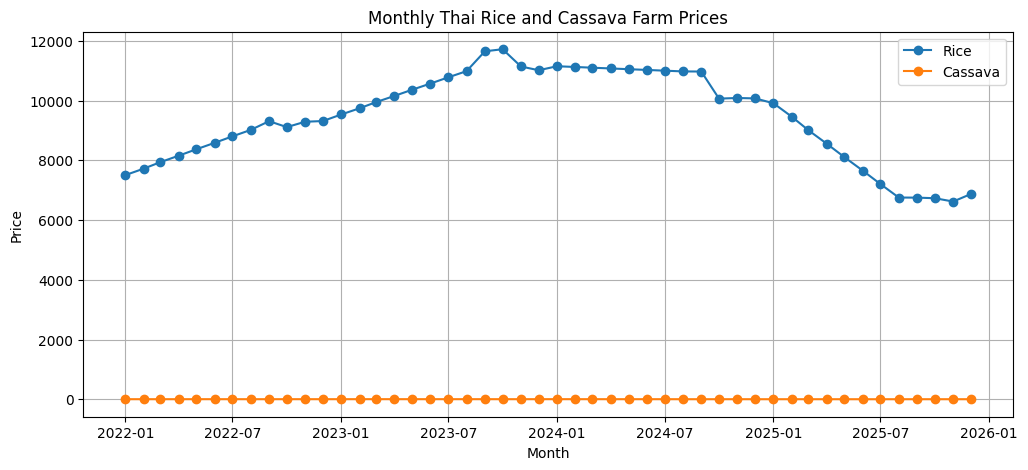

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    price["month"],
    price["rice_price"],
    marker="o",
    label="Rice"
)

plt.plot(
    price["month"],
    price["cassava_price"],
    marker="o",
    label="Cassava"
)

plt.title("Monthly Thai Rice and Cassava Farm Prices")
plt.xlabel("Month")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Crop Price Data

The crop price data is taken from the Bank of Thailand farm price dataset. This project focuses on rice and cassava because both are economically important crops in Thailand and are exposed to climate-sensitive production vulnerabilities.

Since rice and cassava are measured in different units, the model predicts **monthly percentage price change** rather than raw price. This makes the target variable more comparable across crops.

In [16]:
price_long = price.melt(
    id_vars="month",
    value_vars=["rice_price", "cassava_price"],
    var_name="crop",
    value_name="price"
)

price_long["crop"] = price_long["crop"].replace({
    "rice_price": "Rice",
    "cassava_price": "Cassava"
})

price_long = price_long.sort_values(["crop", "month"])

price_long["price_pct_change"] = (
    price_long
    .groupby("crop")["price"]
    .pct_change() * 100
)

price_long.head(10)

,month,crop,price,price_pct_change
48,2022-01-01,Cassava,2.3,NaN
49,2022-02-01,Cassava,2.3,0.000000
50,2022-03-01,Cassava,2.3,0.000000
51,2022-04-01,Cassava,2.3,0.000000
52,2022-05-01,Cassava,2.4,4.347826
53,2022-06-01,Cassava,2.5,4.166667
54,2022-07-01,Cassava,2.5,0.000000
55,2022-08-01,Cassava,2.3,-8.000000
56,2022-09-01,Cassava,2.3,0.000000
57,2022-10-01,Cassava,2.4,4.347826


In [17]:
df = price_long.merge(weather_monthly, on="month", how="inner")

df = df.sort_values(["crop", "month"])

df["lag_1_price_change"] = (
    df.groupby("crop")["price_pct_change"].shift(1)
)

df["lag_1_rainfall_anomaly"] = (
    df.groupby("crop")["rainfall_anomaly_pct"].shift(1)
)

df["lag_1_temp_anomaly"] = (
    df.groupby("crop")["temp_anomaly_c"].shift(1)
)

df["month_number"] = df["month"].dt.month

df["month_sin"] = np.sin(2 * np.pi * df["month_number"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_number"] / 12)

df = df.dropna()

print(df.shape)
df.head()

(92, 19)


,month,crop,price,price_pct_change,rainfall_mm,avg_temp_c,max_temp_c,min_temp_c,calendar_month,rainfall_normal,temp_normal,rainfall_anomaly_pct,temp_anomaly_c,lag_1_price_change,lag_1_rainfall_anomaly,lag_1_temp_anomaly,month_number,month_sin,month_cos
2,2022-03-01,Cassava,2.3,0.000000,72.52,29.490323,34.867097,25.280968,3,38.5850,30.569677,87.948685,-1.079355,0.000000,176.090901,-1.586518,3,1.000000e+00,6.123234e-17
3,2022-04-01,Cassava,2.3,0.000000,88.21,29.783000,35.918667,24.833667,4,54.1175,31.737750,62.997182,-1.954750,0.000000,87.948685,-1.079355,4,8.660254e-01,-5.000000e-01
4,2022-05-01,Cassava,2.4,4.347826,237.90,27.936774,31.677742,24.848710,5,223.6400,30.046048,6.376319,-2.109274,0.000000,62.997182,-1.954750,5,5.000000e-01,-8.660254e-01
5,2022-06-01,Cassava,2.5,4.166667,138.22,28.014667,31.539667,25.025000,6,132.2825,28.864250,4.488500,-0.849583,4.347826,6.376319,-2.109274,6,1.224647e-16,-1.000000e+00
6,2022-07-01,Cassava,2.5,0.000000,244.42,27.723871,31.094839,24.805484,7,214.8050,28.176048,13.786923,-0.452177,4.166667,4.488500,-0.849583,7,-5.000000e-01,-8.660254e-01


## Final Modeling Dataset

The final dataset combines monthly crop price movements with monthly weather anomalies.

The model uses both current-month climate conditions and one-month lagged variables. Lagged variables are included because crop markets may respond with delay to weather stress, supply expectations, and market adjustment.

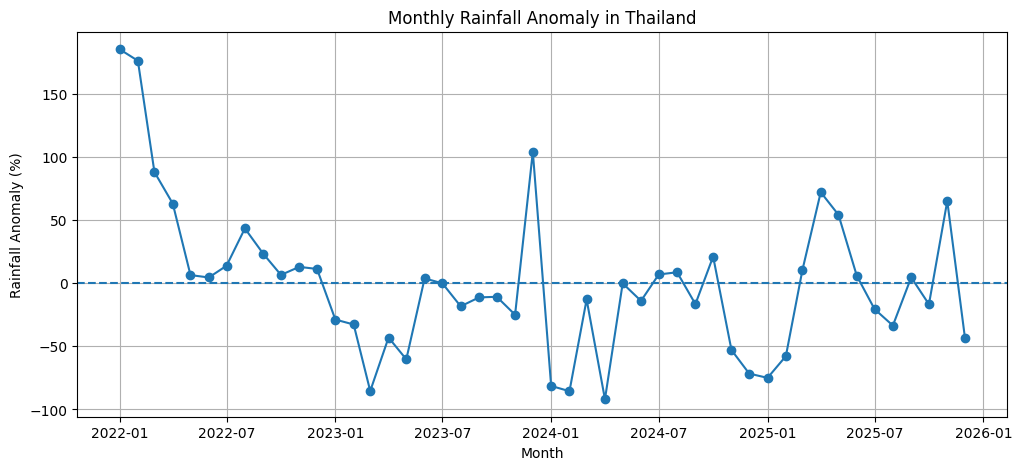

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    weather_monthly["month"],
    weather_monthly["rainfall_anomaly_pct"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Monthly Rainfall Anomaly in Thailand")
plt.xlabel("Month")
plt.ylabel("Rainfall Anomaly (%)")
plt.grid(True)
plt.show()

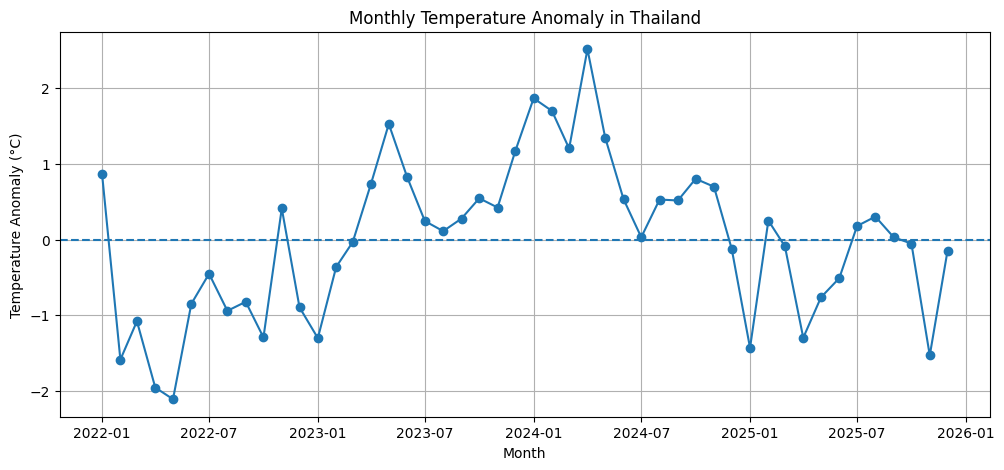

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    weather_monthly["month"],
    weather_monthly["temp_anomaly_c"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Monthly Temperature Anomaly in Thailand")
plt.xlabel("Month")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.show()

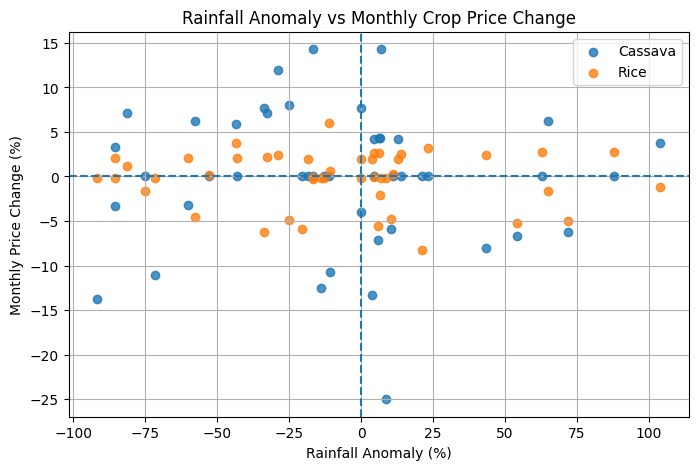

In [20]:
plt.figure(figsize=(8, 5))

for crop in df["crop"].unique():
    subset = df[df["crop"] == crop]
    
    plt.scatter(
        subset["rainfall_anomaly_pct"],
        subset["price_pct_change"],
        label=crop,
        alpha=0.8
    )

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("Rainfall Anomaly vs Monthly Crop Price Change")
plt.xlabel("Rainfall Anomaly (%)")
plt.ylabel("Monthly Price Change (%)")
plt.legend()
plt.grid(True)
plt.show()

## Exploratory Analysis

The exploratory charts show how climate anomalies and crop prices move over time. The scatterplot does not prove causation, but it helps identify whether abnormal rainfall conditions are associated with unusually large price movements.

This is important because agricultural prices are affected by many factors beyond weather, including export demand, input costs, government policy, and market expectations.

In [21]:
features = [
    "crop",
    "rainfall_anomaly_pct",
    "temp_anomaly_c",
    "lag_1_price_change",
    "lag_1_rainfall_anomaly",
    "lag_1_temp_anomaly",
    "month_sin",
    "month_cos"
]

target = "price_pct_change"

X = df[features]
y = df[target]

X.head()

,crop,rainfall_anomaly_pct,temp_anomaly_c,lag_1_price_change,lag_1_rainfall_anomaly,lag_1_temp_anomaly,month_sin,month_cos
2,Cassava,87.948685,-1.079355,0.000000,176.090901,-1.586518,1.000000e+00,6.123234e-17
3,Cassava,62.997182,-1.954750,0.000000,87.948685,-1.079355,8.660254e-01,-5.000000e-01
4,Cassava,6.376319,-2.109274,0.000000,62.997182,-1.954750,5.000000e-01,-8.660254e-01
5,Cassava,4.488500,-0.849583,4.347826,6.376319,-2.109274,1.224647e-16,-1.000000e+00
6,Cassava,13.786923,-0.452177,4.166667,4.488500,-0.849583,-5.000000e-01,-8.660254e-01


In [22]:
df_model = df.copy().sort_values(["month", "crop"])

train = df_model[df_model["month"] < "2025-01-01"]
test = df_model[df_model["month"] >= "2025-01-01"]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 68
Testing rows: 24


## Modeling Approach

A time-based train/test split is used instead of a random split. This is more realistic because the model is trained on earlier months and tested on later months.

Two interpretable Scikit-Learn models are compared:

- Random Forest Regressor
- Gradient Boosting Regressor

The main evaluation metric is Mean Absolute Error because it is easy to interpret as the average prediction error in percentage points.

In [23]:
numeric_features = [
    "rainfall_anomaly_pct",
    "temp_anomaly_c",
    "lag_1_price_change",
    "lag_1_rainfall_anomaly",
    "lag_1_temp_anomaly",
    "month_sin",
    "month_cos"
]

categorical_features = ["crop"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        "pipeline": pipe,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results_df = pd.DataFrame(results).T[["MAE", "RMSE", "R2"]]
results_df

,MAE,RMSE,R2
Random Forest,5.686769,7.210281,-0.67531
Gradient Boosting,6.113129,8.339636,-1.241222


In [24]:
best_model_name = min(results, key=lambda name: results[name]["MAE"])
best_model = results[best_model_name]["pipeline"]

print("Best model:", best_model_name)
print("MAE:", round(results[best_model_name]["MAE"], 3))
print("RMSE:", round(results[best_model_name]["RMSE"], 3))
print("R2:", round(results[best_model_name]["R2"], 3))

Best model: Random Forest
MAE: 5.687
RMSE: 7.21
R2: -0.675


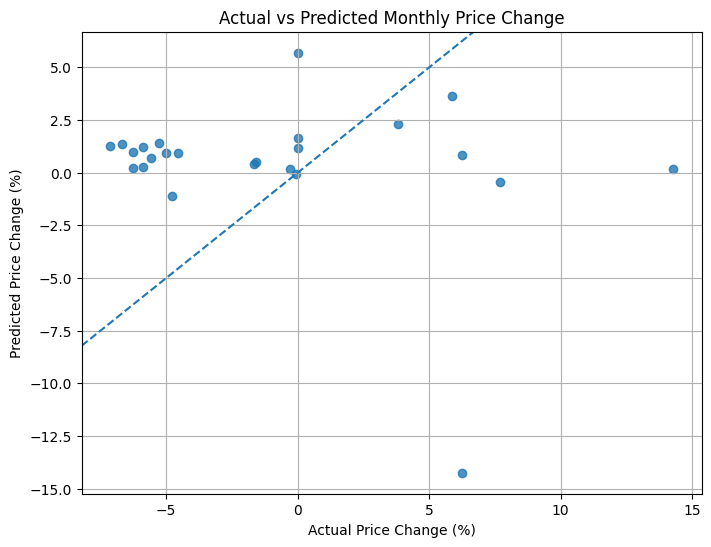

,month,crop,price_pct_change,predicted_price_change
36,2025-01-01,Cassava,0.000000,5.693255
84,2025-01-01,Rice,-1.594942,0.507109
37,2025-02-01,Cassava,6.250000,0.821354
85,2025-02-01,Rice,-4.551303,0.940050
38,2025-03-01,Cassava,-5.882353,0.288961
86,2025-03-01,Rice,-4.768324,-1.114896
39,2025-04-01,Cassava,-6.250000,0.990282
87,2025-04-01,Rice,-5.007078,0.932672
40,2025-05-01,Cassava,-6.666667,1.377348
88,2025-05-01,Rice,-5.271001,1.403614


In [25]:
test_results = test.copy()
test_results["predicted_price_change"] = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    test_results["price_pct_change"],
    test_results["predicted_price_change"],
    alpha=0.8
)

plt.axline((0, 0), slope=1, linestyle="--")

plt.title("Actual vs Predicted Monthly Price Change")
plt.xlabel("Actual Price Change (%)")
plt.ylabel("Predicted Price Change (%)")
plt.grid(True)
plt.show()

test_results[["month", "crop", "price_pct_change", "predicted_price_change"]].head(12)

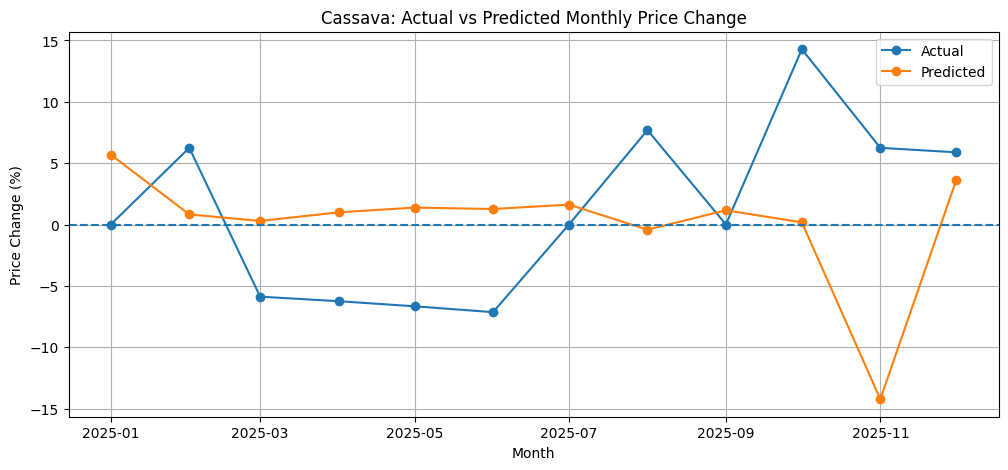

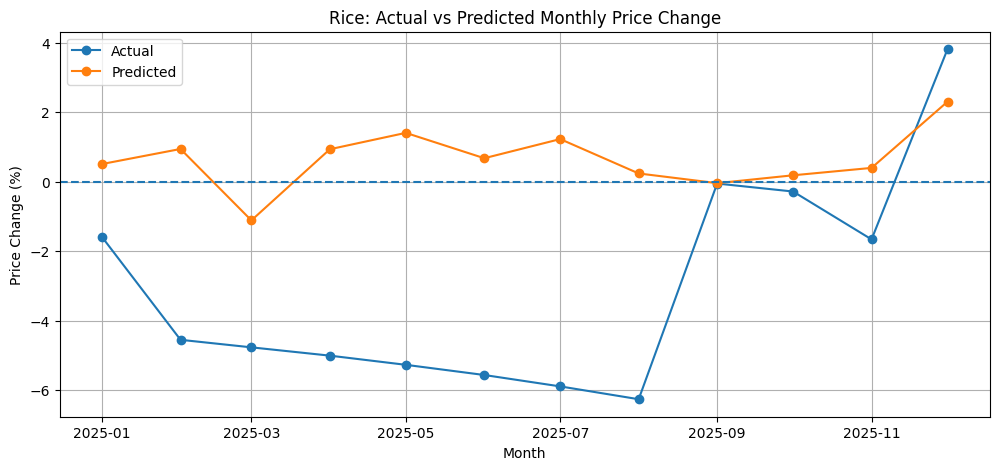

In [26]:
for crop in test_results["crop"].unique():
    subset = test_results[test_results["crop"] == crop]
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(
        subset["month"],
        subset["price_pct_change"],
        marker="o",
        label="Actual"
    )
    
    plt.plot(
        subset["month"],
        subset["predicted_price_change"],
        marker="o",
        label="Predicted"
    )
    
    plt.axhline(0, linestyle="--")
    
    plt.title(f"{crop}: Actual vs Predicted Monthly Price Change")
    plt.xlabel("Month")
    plt.ylabel("Price Change (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

importance = pd.DataFrame({
    "feature": features,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance

,feature,importance
1,rainfall_anomaly_pct,0.069540
7,month_cos,0.040656
4,lag_1_rainfall_anomaly,0.011506
0,crop,0.001605
5,lag_1_temp_anomaly,-0.000910
2,temp_anomaly_c,-0.016404
6,month_sin,-0.049023
3,lag_1_price_change,-0.287701


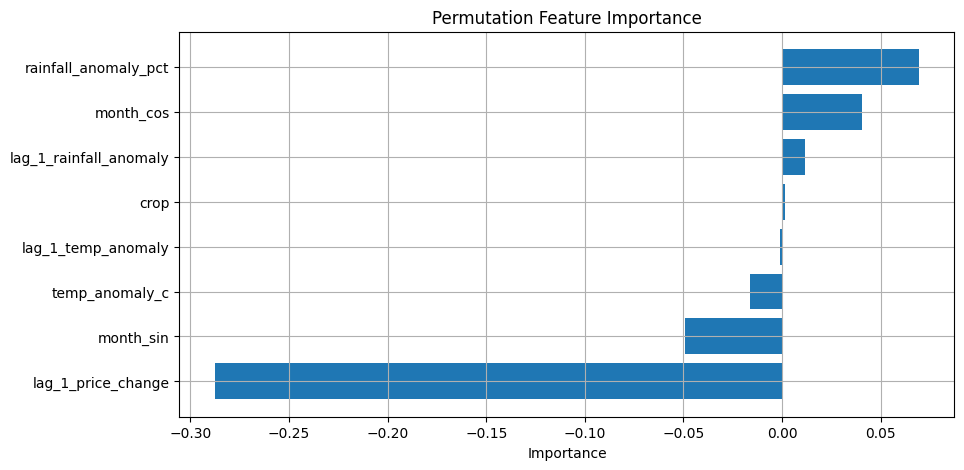

In [28]:
plt.figure(figsize=(10, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance")
plt.xlabel("Importance")
plt.grid(True)
plt.show()

## Model Interpretation

The feature importance chart shows which variables were most useful for predicting monthly crop price changes in the test period. This helps make the model more interpretable than a black-box prediction system.

As the dataset is small, the feature importance values should be interpreted as suggestive rather than definitive. As outlined, the goal is to build a transparent stress-testing tool for climate-sensitive crop price risk.

In [29]:
def simulate_climate_shock(
    crop,
    rainfall_shock_pct=0,
    temp_shock_c=0,
    base_month=8
):
    """
    Simulates predicted monthly crop price change under a climate shock.

    crop: "Rice" or "Cassava"
    rainfall_shock_pct: example -10 means rainfall is 10% lower than expected
    temp_shock_c: example 1 means temperature is 1°C higher than expected
    base_month: 1-12, where 8 = August
    """
    
    crop_data = df[df["crop"] == crop].sort_values("month")
    latest = crop_data.iloc[-1]
    
    scenario = pd.DataFrame({
        "crop": [crop],
        "rainfall_anomaly_pct": [rainfall_shock_pct],
        "temp_anomaly_c": [temp_shock_c],
        "lag_1_price_change": [latest["price_pct_change"]],
        "lag_1_rainfall_anomaly": [latest["rainfall_anomaly_pct"]],
        "lag_1_temp_anomaly": [latest["temp_anomaly_c"]],
        "month_sin": [np.sin(2 * np.pi * base_month / 12)],
        "month_cos": [np.cos(2 * np.pi * base_month / 12)]
    })
    
    predicted_change = best_model.predict(scenario)[0]
    
    return predicted_change

In [30]:
rice_result = simulate_climate_shock(
    crop="Rice",
    rainfall_shock_pct=-10,
    temp_shock_c=1,
    base_month=8
)

cassava_result = simulate_climate_shock(
    crop="Cassava",
    rainfall_shock_pct=-10,
    temp_shock_c=1,
    base_month=8
)

print("Climate shock scenario:")
print("10% lower rainfall than expected and 1°C higher temperature in August")
print()
print(f"Rice predicted monthly price change: {rice_result:.2f}%")
print(f"Cassava predicted monthly price change: {cassava_result:.2f}%")

Climate shock scenario:
10% lower rainfall than expected and 1°C higher temperature in August

Rice predicted monthly price change: 0.71%
Cassava predicted monthly price change: 0.19%


In [31]:
scenarios = []

for crop in ["Rice", "Cassava"]:
    for rain_shock in [-30, -20, -10, 0, 10, 20, 30]:
        prediction = simulate_climate_shock(
            crop=crop,
            rainfall_shock_pct=rain_shock,
            temp_shock_c=1,
            base_month=8
        )
        
        scenarios.append({
            "crop": crop,
            "rainfall_shock_pct": rain_shock,
            "temperature_shock_c": 1,
            "predicted_price_change_pct": prediction
        })

scenario_df = pd.DataFrame(scenarios)

scenario_df

,crop,rainfall_shock_pct,temperature_shock_c,predicted_price_change_pct
0,Rice,-30,1,0.798947
1,Rice,-20,1,0.770500
2,Rice,-10,1,0.713922
3,Rice,0,1,0.695780
4,Rice,10,1,0.611154
5,Rice,20,1,0.246618
6,Rice,30,1,0.252280
7,Cassava,-30,1,0.326920
8,Cassava,-20,1,0.239411
9,Cassava,-10,1,0.189681


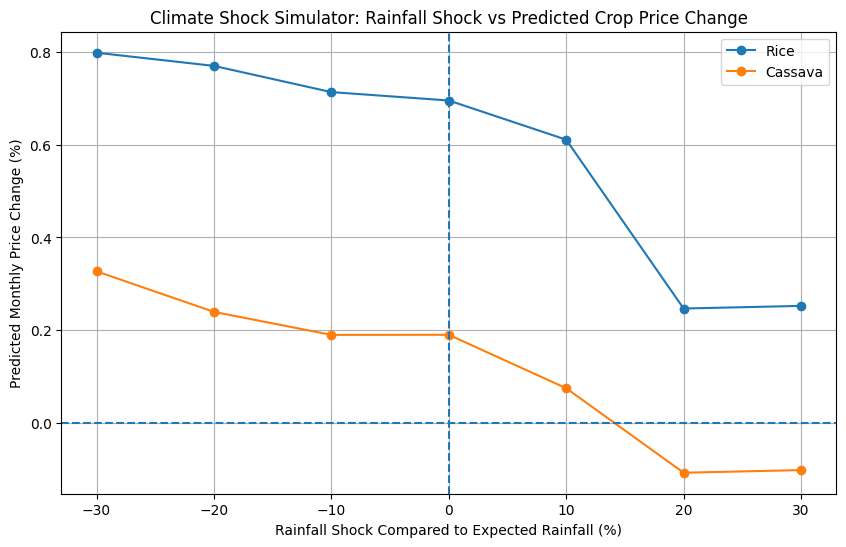

In [32]:
plt.figure(figsize=(10, 6))

for crop in scenario_df["crop"].unique():
    subset = scenario_df[scenario_df["crop"] == crop]
    
    plt.plot(
        subset["rainfall_shock_pct"],
        subset["predicted_price_change_pct"],
        marker="o",
        label=crop
    )

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("Climate Shock Simulator: Rainfall Shock vs Predicted Crop Price Change")
plt.xlabel("Rainfall Shock Compared to Expected Rainfall (%)")
plt.ylabel("Predicted Monthly Price Change (%)")
plt.legend()
plt.grid(True)
plt.show()

## Climate Shock Simulator

The simulator allows a user to test hypothetical climate scenarios. For example, a 10% rainfall shortfall and a 1°C temperature increase can be entered as a stress scenario for rice or cassava.

The model then estimates the predicted monthly price change based on historical relationships between crop price movements and weather anomalies.

This makes the notebook a simple economic planning tool for thinking about climate risk and agricultural price volatility.

## Economic Interpretation

The model suggests that unusual climate conditions can be used as stress-test inputs for agricultural price analysis. A rainfall shock does not directly “cause” a price change in this model, but it helps estimate how prices have historically moved during months with unusual weather patterns.

This matters because small-scale farmers are often price takers. If climate shocks reduce expected yields or create uncertainty in supply, market prices may become more volatile. Even when higher prices occur, farmers do not always benefit equally because crop losses, debt obligations, transport costs, and bargaining power can reduce the income gains from price increases.

The simulator therefore works best as a structural planning tool rather than a trading or forecasting tool. It can help policymakers, cooperatives, and agricultural planners think about how climate risk may transmit into rural income instability.

## Limitations

First, the weather dataset only covers 2022-2025, so the model has a small number of monthly observations which may limit accuracy.

Second, crop prices are affected by many non-weather factors, including export demand, government policy, fertilizer costs, fuel prices, exchange rates, stock levels, and global commodity cycles.

Third, the model captures association rather than pure causation. A predicted price increase after a rainfall shock does not prove that rainfall alone caused the increase.

Fourthly,the official rice price series contains missing monthly observations, which were filled using interpolation. This allows the model to maintain a continuous monthly dataset, but rice-specific predictions should be interpreted cautiously because some values are estimated.

Finally, the climate anomaly baseline is calculated within the available dataset rather than using a long-term 30-year climate normal. A longer weather history would make the anomaly measurement stronger.

## Conclusion

This project built a machine learning simulator for rice and cassava price changes under climate shock scenarios. By combining monthly weather anomalies with crop price data, the notebook shows how rainfall and temperature deviations can be used to stress-test agricultural price risk.

The strongest part of the project is the ability to translate climate shocks into an interpretable economic scenario. This makes the notebook useful for thinking about rural income instability and climate-sensitive structural planning in Thailand.